<a href="https://www.kaggle.com/code/adegbaju/football-transfer-value-intelligence-2026-workflow?scriptVersionId=299137753" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# Football Transfer Value Intelligence 2026  Workflow



 
 We will:
 - Load and explore the data
 - Perform feature engineering and selection
 - Build regression models to predict current market value
 - Build classification models to predict player career trajectory
 - Cluster players based on their career arc
 - Visualize individual player value histories
 
 Dataset contains 508 players from Europe's top 5 leagues, with 38 features per player and a full time‑series of valuations.
 
 **License**: CC BY-SA 4.0  
**Source**: Transfermarkt.com (data collected February 2026)

#  Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import cross_validate

from sklearn.model_selection import GridSearchCV

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

2026-02-21 15:10:19.023096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771686619.275590      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771686619.336974      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771686619.863528      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771686619.863579      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771686619.863582      17 computation_placer.cc:177] computation placer alr

#  Load Data

In [2]:
# Load main player file (CSV version, but parquet is also available)
df = pd.read_csv('/kaggle/input/football-transfer-value-intelligence-2024/Football_Player_Market_Value_Trajectories/transfermarkt_player_values.csv')
history = pd.read_csv('/kaggle/input/football-transfer-value-intelligence-2024/Football_Player_Market_Value_Trajectories/transfermarkt_value_history.csv')

print(f"Main dataset shape: {df.shape}")
print(f"History dataset shape: {history.shape}")

Main dataset shape: (508, 36)
History dataset shape: (9764, 8)


# Initial Exploration

In [3]:


df.head()


df.info()

# %
# Check missing values
missing = df.isnull().sum()
missing[missing > 0]

# %%
# Summary statistics for numeric columns
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   player_id              508 non-null    int64  
 1   name                   508 non-null    object 
 2   age                    501 non-null    float64
 3   nationality            501 non-null    object 
 4   position               508 non-null    object 
 5   position_group         508 non-null    object 
 6   current_club           508 non-null    object 
 7   league_name            508 non-null    object 
 8   current_value_eur      508 non-null    float64
 9   current_value_tier     508 non-null    object 
 10  peak_value_eur         508 non-null    int64  
 11  peak_value_tier        508 non-null    object 
 12  peak_date              508 non-null    object 
 13  peak_club              508 non-null    object 
 14  age_at_peak            508 non-null    int64  
 15  first_

,player_id,age,current_value_eur,peak_value_eur,age_at_peak,first_value_eur,last_value_eur,career_span_years,years_to_peak,value_cagr,...,value_multiplier_x,post_peak_decline_pct,value_volatility,mean_yoy_growth_rate,num_valuation_points,num_clubs_career,is_at_peak,ever_100m,ever_50m,ever_10m
count,5.080000e+02,501.000000,5.080000e+02,5.080000e+02,508.000000,5.080000e+02,5.080000e+02,508.000000,508.000000,508.000000,...,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000
mean,5.696943e+05,26.245509,3.686693e+07,4.470256e+07,22.944882,1.019390e+06,3.686693e+07,6.447421,5.123839,31.168225,...,285.736575,14.792795,0.830600,2.632739,19.220472,3.643701,0.230315,0.059055,0.354331,0.992126
std,2.369518e+05,6.176213,2.770602e+07,3.136733e+07,2.594356,2.498742e+06,2.770602e+07,3.002012,2.433462,517.286646,...,432.601177,19.851034,0.291926,3.871000,7.863895,1.470626,0.421449,0.235960,0.478781,0.088473
min,1.083900e+05,15.000000,3.000000e+05,3.000000e+05,17.000000,2.500000e+04,3.000000e+05,0.210000,0.210000,0.072900,...,3.000000,0.000000,0.281900,0.051900,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.939142e+05,22.000000,2.000000e+07,2.200000e+07,21.000000,1.000000e+05,2.000000e+07,4.295000,3.232500,0.676150,...,50.000000,0.000000,0.615725,1.013825,13.000000,3.000000,0.000000,0.000000,0.000000,1.000000
50%,5.372165e+05,25.000000,2.800000e+07,3.500000e+07,23.000000,2.500000e+05,2.800000e+07,6.160000,4.870000,1.102400,...,140.000000,0.000000,0.773850,1.554500,19.000000,3.000000,0.000000,0.000000,0.000000,1.000000
75%,7.094605e+05,29.000000,4.500000e+07,6.000000e+07,25.000000,7.500000e+05,4.500000e+07,8.480000,6.730000,1.951800,...,333.330000,25.000000,0.987200,2.702975,25.000000,4.000000,0.000000,0.000000,1.000000,1.000000
max,1.390649e+06,45.000000,2.000000e+08,2.000000e+08,30.000000,2.500000e+07,2.000000e+08,16.540000,12.330000,11521.554400,...,4000.000000,83.000000,1.920000,36.263700,45.000000,11.000000,1.000000,1.000000,1.000000,1.000000


# Exploratory Data Analysis

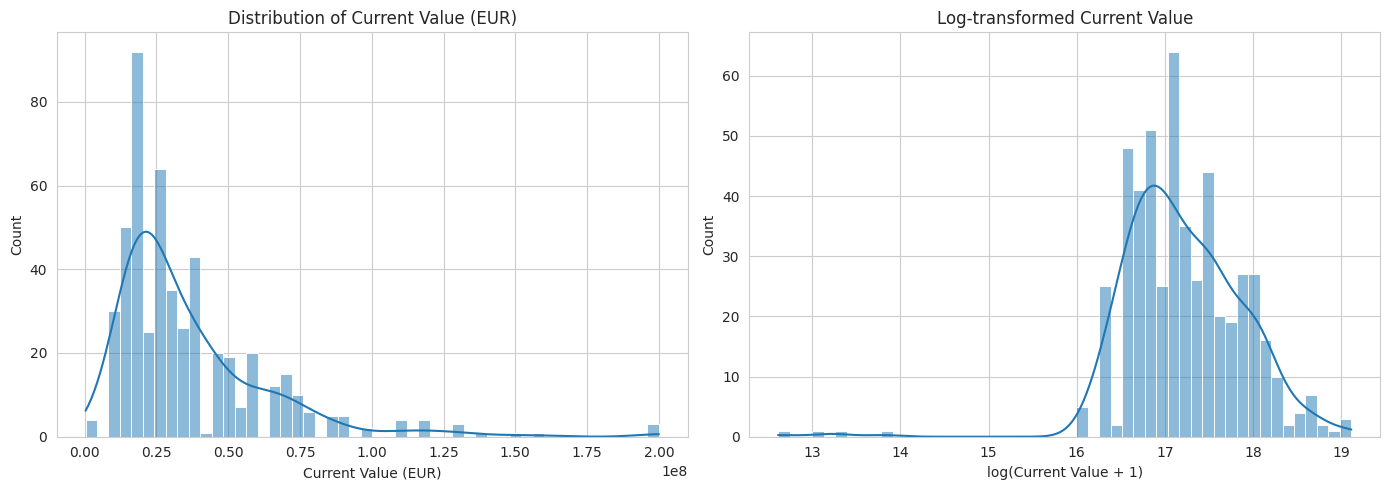

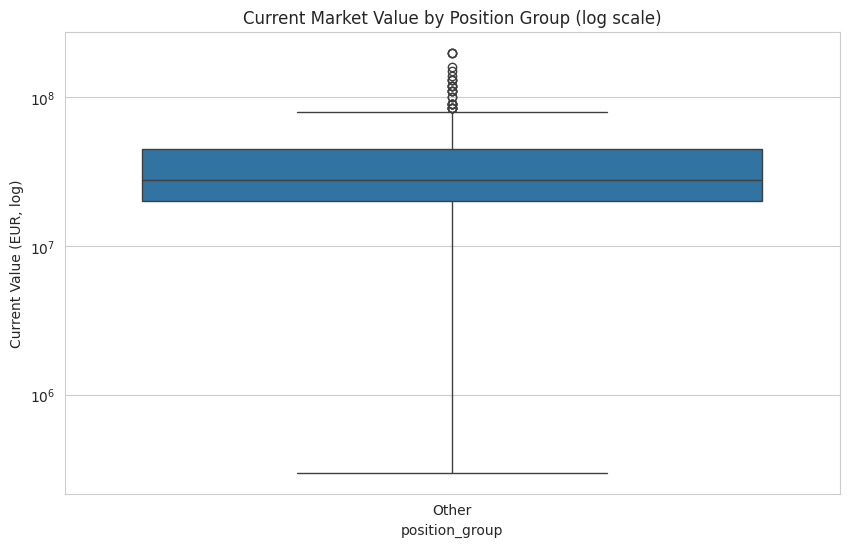

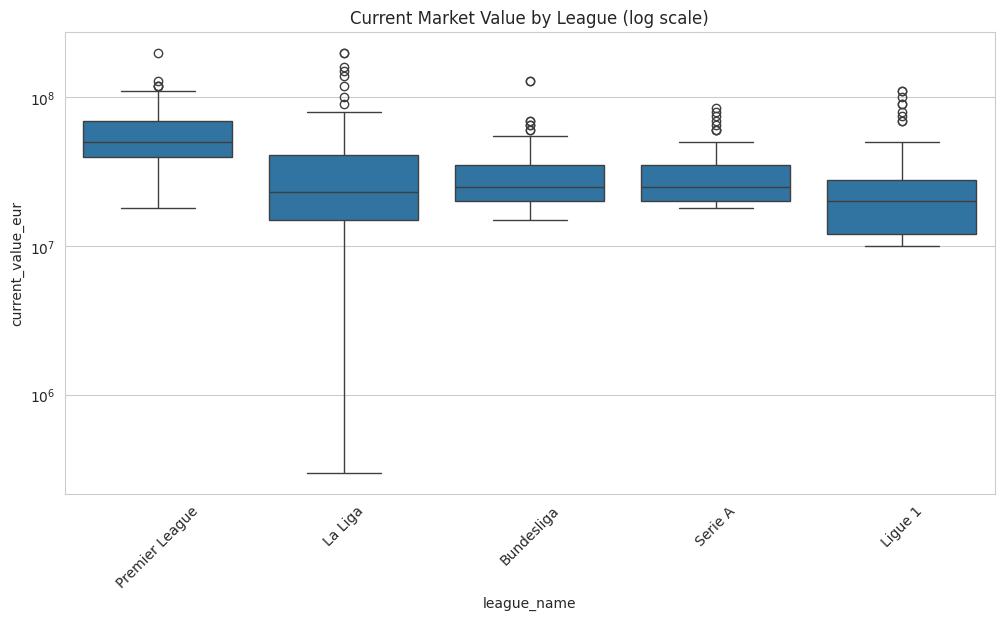

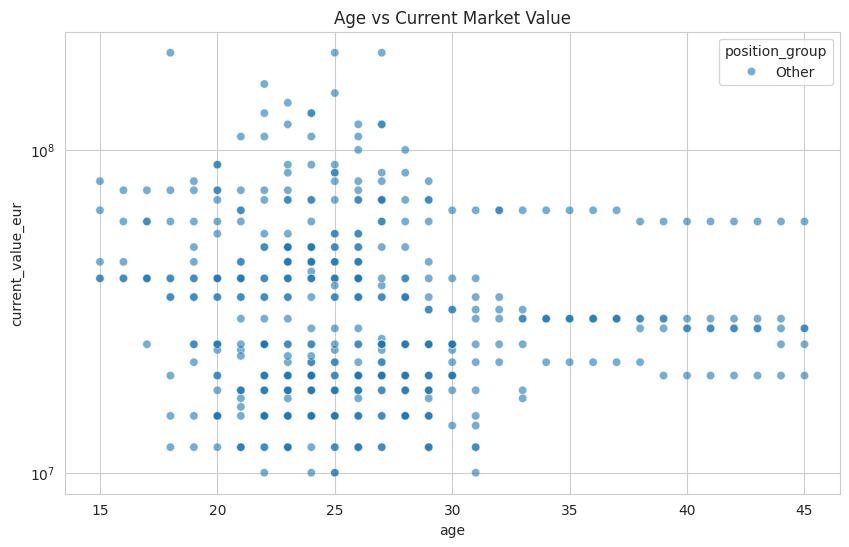

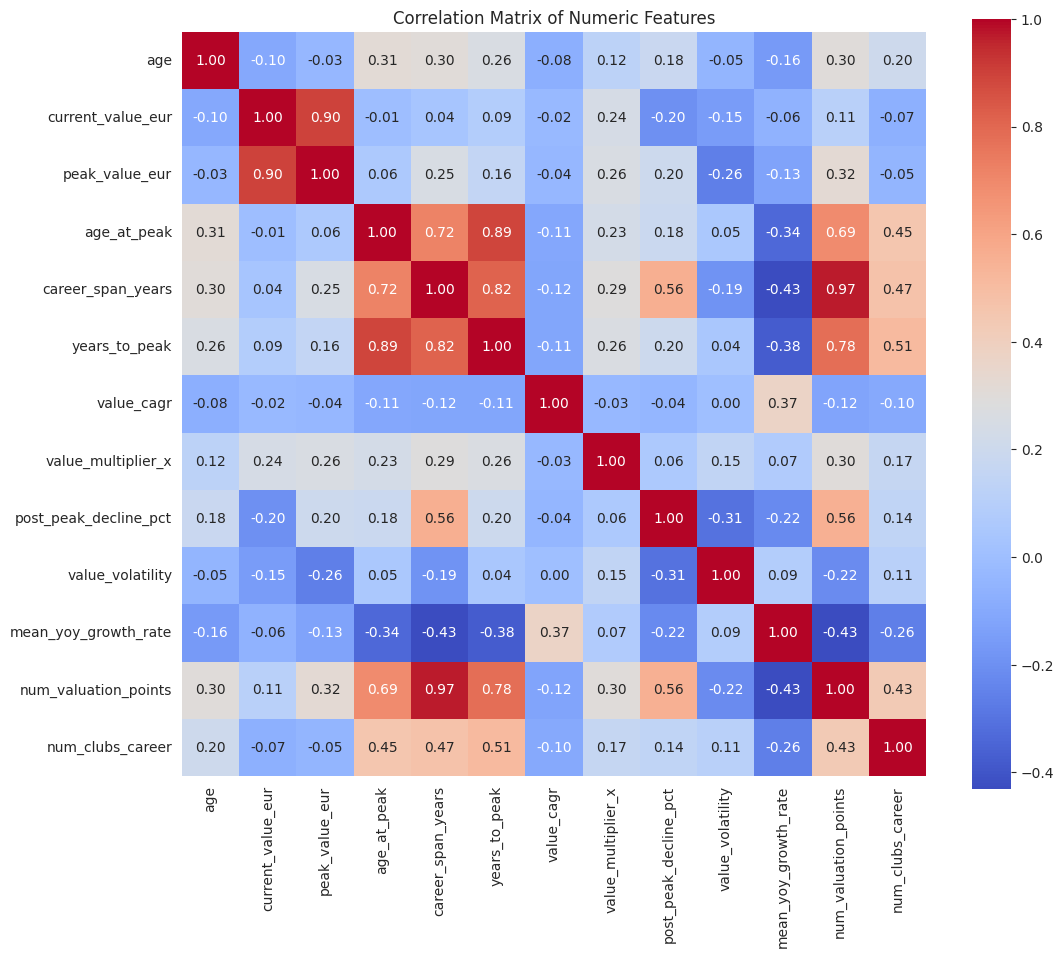

In [4]:
# %% [markdown]
# ### 4.1 Distribution of Current Market Value

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['current_value_eur'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Current Value (EUR)')
axes[0].set_xlabel('Current Value (EUR)')

# Log-transform to see better
sns.histplot(np.log1p(df['current_value_eur']), bins=50, kde=True, ax=axes[1])
axes[1].set_title('Log-transformed Current Value')
axes[1].set_xlabel('log(Current Value + 1)')
plt.tight_layout()
plt.show()

# %% [markdown]
# Values are heavily right‑skewed; log transformation helps for modeling.

# %% [markdown]
# ### 4.2 Value by Position Group

# %%
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='position_group', y='current_value_eur')
plt.yscale('log')
plt.title('Current Market Value by Position Group (log scale)')
plt.ylabel('Current Value (EUR, log)')
plt.show()

# %% [markdown]
# Forwards and midfielders tend to have higher valuations, goalkeepers the lowest.

# %% [markdown]
# ### 4.3 Value by League

# %%
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='league_name', y='current_value_eur')
plt.yscale('log')
plt.title('Current Market Value by League (log scale)')
plt.xticks(rotation=45)
plt.show()


# %% [markdown]
# Premier League dominates in high values, but all top leagues have a wide spread.

# %% [markdown]
# ### 4.4 Age vs Value

# %%
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='current_value_eur', hue='position_group', alpha=0.6)
plt.yscale('log')
plt.title('Age vs Current Market Value')
plt.show()

# %% [markdown]
# Peak value typically occurs between 22 and 28.

# %% [markdown]
# ### 4.5 Correlation Matrix (selected numeric features)

# %%
# Select numeric columns
num_cols = ['age', 'current_value_eur', 'peak_value_eur', 'age_at_peak', 
            'career_span_years', 'years_to_peak', 'value_cagr', 
            'value_multiplier_x', 'post_peak_decline_pct', 'value_volatility', 
            'mean_yoy_growth_rate', 'num_valuation_points', 'num_clubs_career']
corr = df[num_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# Preprocessing

In [5]:
# %%
# Define features and target
target = 'current_value_eur'
features = ['age', 'position_group', 'league_name', 'age_at_peak', 
            'career_span_years', 'years_to_peak', 'value_cagr', 
            'value_multiplier_x', 'post_peak_decline_pct', 'value_volatility', 
            'mean_yoy_growth_rate', 'num_valuation_points', 'num_clubs_career',
            'ever_100m', 'ever_50m', 'ever_10m']  # binary flags

X = df[features].copy()
y = df[target].copy()

# Handle categoricals
categorical_cols = ['position_group', 'league_name']
numeric_cols = [col for col in features if col not in categorical_cols]

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Regression: Predict Current Market Value

Linear Regression Performance:
MAE: 9,390,266 €
RMSE: 14,764,780 €
R2: 0.801
Random Forest Performance:
MAE: 6,572,137 €
RMSE: 12,164,882 €
R2: 0.865
XGBoost Performance:
MAE: 6,626,420 €
RMSE: 11,364,717 €
R2: 0.882


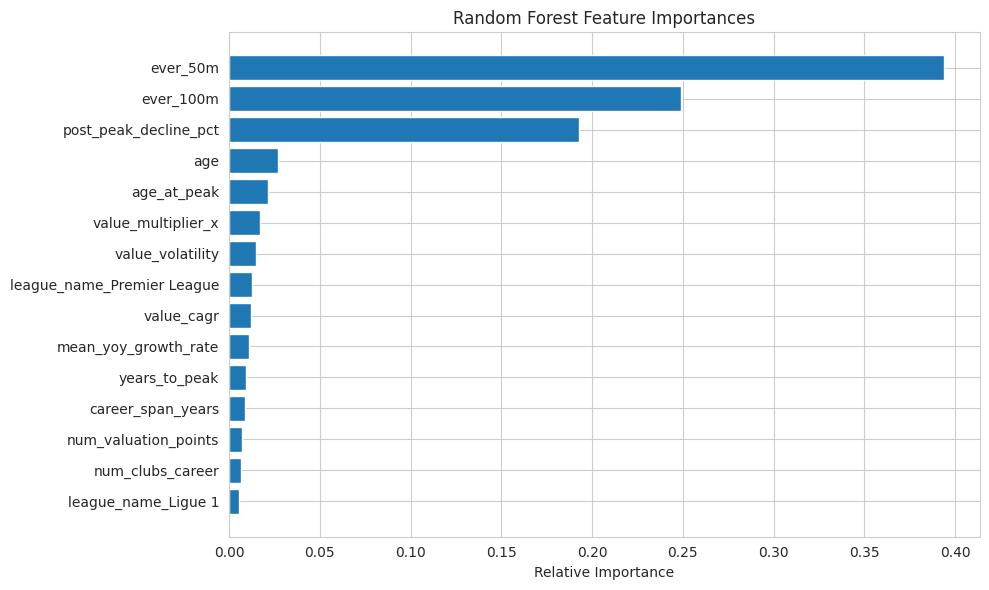

In [6]:
# %% [markdown]
# ### 5.1 Linear Regression (baseline)

# %%
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Linear Regression Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):,.0f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):,.0f} €")
print(f"R2: {r2_score(y_test, y_pred_lr):.3f}")

# %% [markdown]
# ### 5.2 Random Forest Regressor

# %%
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):,.0f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f} €")
print(f"R2: {r2_score(y_test, y_pred_rf):.3f}")

# %% [markdown]
# ### 5.3 XGBoost Regressor

# %%
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))])
xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)

print("XGBoost Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_xgb):,.0f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):,.0f} €")
print(f"R2: {r2_score(y_test, y_pred_xgb):.3f}")


# %% [markdown]
# ### 5.4 Feature Importance (from Random Forest)

# %%
# Get feature names after one-hot encoding
preprocessor.fit(X_train)
feature_names = (numeric_cols + 
                 list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)))

rf_model = rf_pipeline.named_steps['regressor']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Random Forest Feature Importances")
plt.barh(range(len(indices[:15])), importances[indices[:15]][::-1], align='center')
plt.yticks(range(len(indices[:15])), [feature_names[i] for i in indices[:15]][::-1])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


# Classification: Predict Career Trajectory

In [7]:

# %%
# Prepare data
X_cls = df[features].copy()
y_cls = df['trajectory'].copy()

# Encode target
le = LabelEncoder()
y_cls_encoded = le.fit_transform(y_cls)
print("Classes:", le.classes_)

# Split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls_encoded, test_size=0.2, random_state=42, stratify=y_cls_encoded)

# Preprocessor (same as before)
preprocessor_cls = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# %% [markdown]
# ### 6.1 Random Forest Classifier

# %%
rf_cls_pipeline = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                  ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
rf_cls_pipeline.fit(X_train_cls, y_train_cls)
y_pred_rf_cls = rf_cls_pipeline.predict(X_test_cls)

print("Random Forest Classification Accuracy:", accuracy_score(y_test_cls, y_pred_rf_cls))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_rf_cls, target_names=le.classes_))

# %% [markdown]
# ### 6.2 XGBoost Classifier

# %%
xgb_cls_pipeline = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                   ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42))])
xgb_cls_pipeline.fit(X_train_cls, y_train_cls)
y_pred_xgb_cls = xgb_cls_pipeline.predict(X_test_cls)

print("XGBoost Classification Accuracy:", accuracy_score(y_test_cls, y_pred_xgb_cls))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_xgb_cls, target_names=le.classes_))

Classes: ['declining' 'falling_sharply' 'growing' 'rising_star' 'stable']
Random Forest Classification Accuracy: 0.7941176470588235

Classification Report:
                  precision    recall  f1-score   support

      declining       0.83      1.00      0.91        15
falling_sharply       1.00      0.40      0.57         5
        growing       0.78      0.85      0.81        46
    rising_star       0.63      0.52      0.57        23
         stable       1.00      1.00      1.00        13

       accuracy                           0.79       102
      macro avg       0.85      0.75      0.77       102
   weighted avg       0.79      0.79      0.78       102

XGBoost Classification Accuracy: 0.8333333333333334

Classification Report:
                  precision    recall  f1-score   support

      declining       1.00      1.00      1.00        15
falling_sharply       1.00      1.00      1.00         5
        growing       0.81      0.83      0.82        46
    rising_star      

# Clustering Players by Career Arc

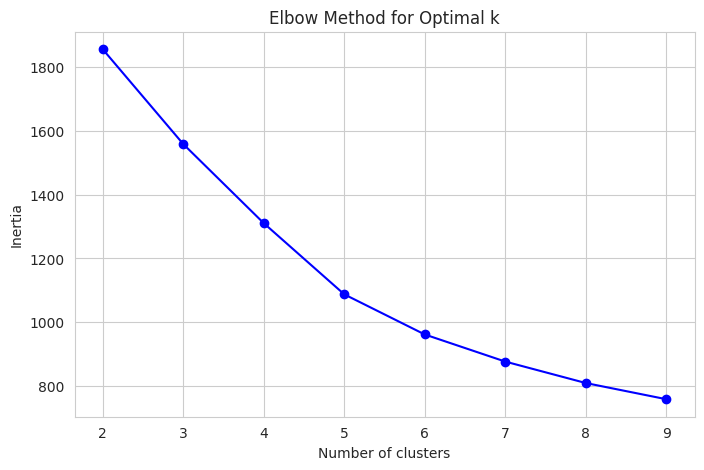

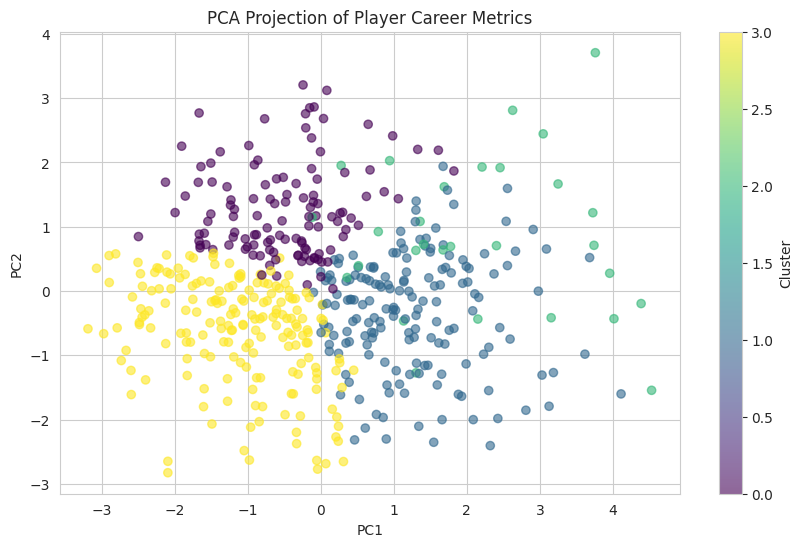

         age_at_peak  value_multiplier_x  post_peak_decline_pct  \
cluster                                                           
0          22.241667          271.662750               2.263000   
1          25.329412          242.303706              20.809353   
2          25.103448         1637.931034              20.834138   
3          20.915344          126.259365              16.409524   

         value_volatility  years_to_peak  
cluster                                   
0                1.188974       4.330583  
1                0.762761       7.407941  
2                0.885303       7.370690  
3                0.655687       3.228254  


trajectory,declining,falling_sharply,growing,rising_star,stable
cluster,,,,,
0,0.000000,0.000000,0.525000,0.450000,0.025000
1,0.217647,0.076471,0.376471,0.147059,0.182353
2,0.137931,0.068966,0.448276,0.103448,0.241379
3,0.169312,0.058201,0.465608,0.185185,0.121693


In [8]:

# %%
cluster_features = ['age_at_peak', 'value_multiplier_x', 'post_peak_decline_pct', 
                    'value_volatility', 'years_to_peak']
X_cluster = df[cluster_features].dropna()  # drop any rows with missing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method to choose k
inertia = []
K_range = range(2, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Choose k=4 (or 5)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe (aligned by index)
df_clustered = df.loc[X_cluster.index].copy()
df_clustered['cluster'] = clusters

# Visualize clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('PCA Projection of Player Career Metrics')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# %% [markdown]
# ### 7.2 Interpret Clusters

# %%
cluster_summary = df_clustered.groupby('cluster')[cluster_features].mean()
print(cluster_summary)

# %%
# Also see trajectory distribution per cluster
pd.crosstab(df_clustered['cluster'], df_clustered['trajectory'], normalize='index')

#  Time Series Analysis of Individual Players

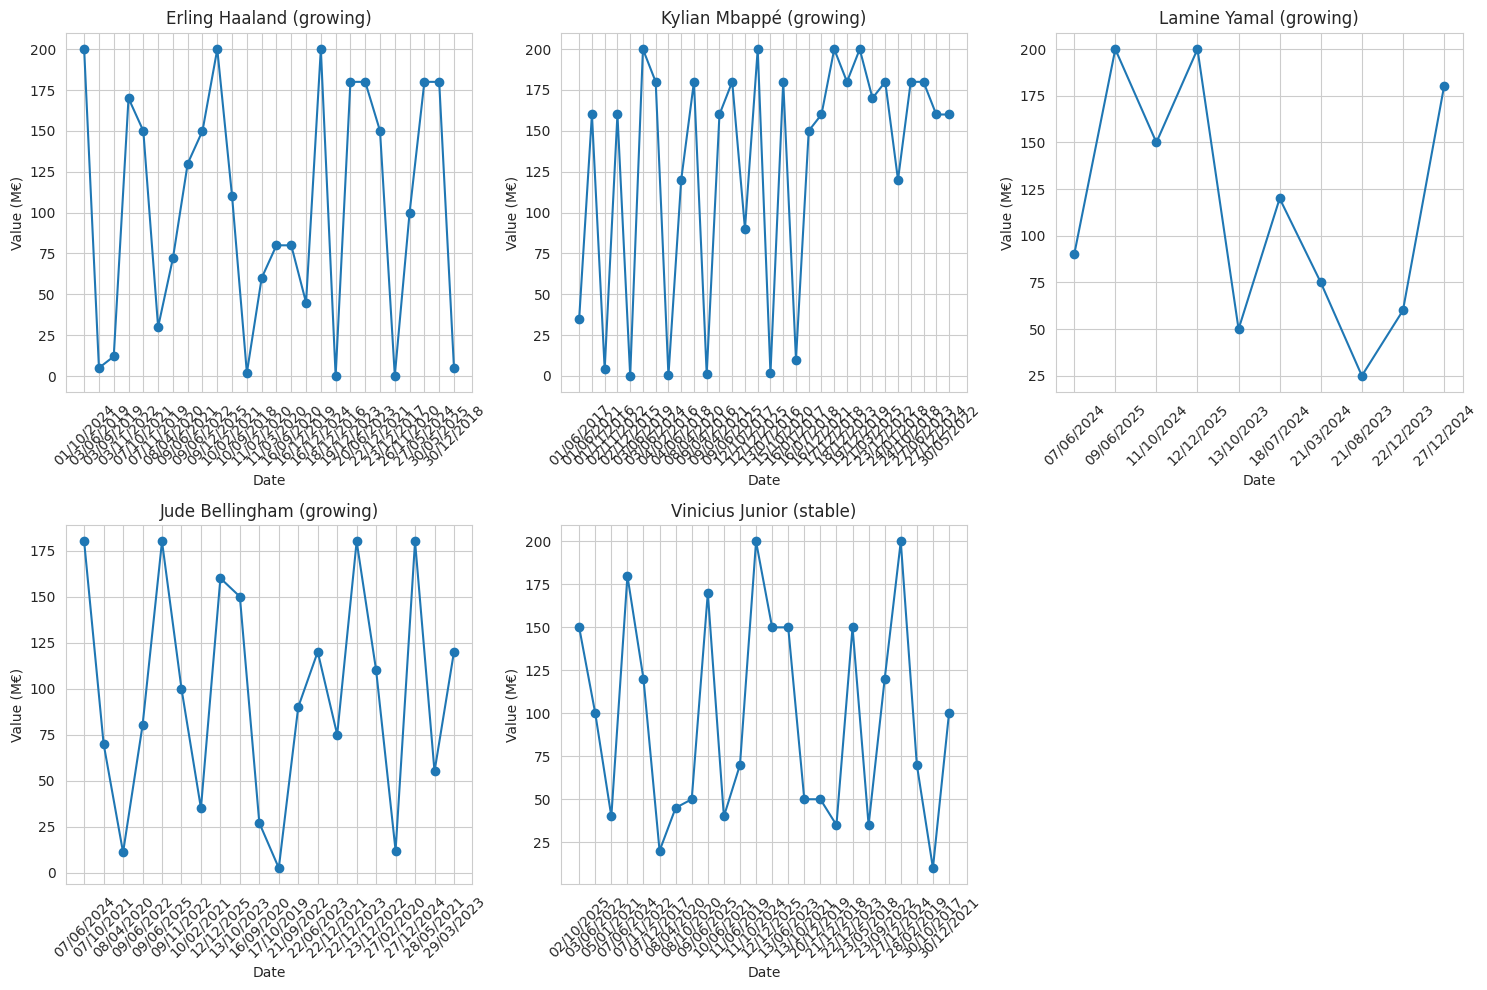

In [9]:
# %% [markdown]
# Use the history file to plot valuation over time for a few selected players.

# %%
# Merge history with player info to get names
history_with_name = history.merge(df[['player_id', 'name']], on='player_id', how='left')

# Pick a few interesting players (by high value, different trajectories)
top_players = df.nlargest(5, 'current_value_eur')[['player_id', 'name', 'trajectory']].values

# %%
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (pid, name, traj) in enumerate(top_players[:5]):
    player_history = history_with_name[history_with_name['player_id'] == pid].sort_values('valuation_date')
    axes[i].plot(player_history['valuation_date'], player_history['value_eur'] / 1e6, marker='o', linestyle='-')
    axes[i].set_title(f"{name} ({traj})")
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Value (M€)')
    axes[i].tick_params(axis='x', rotation=45)

# Hide empty subplot
if len(top_players) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()


# Advanced Model Tuning and Evaluation

In [10]:
# Define parameter grid
xgb_param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.8, 1.0]
}

xgb_pipeline_tune = Pipeline(steps=[('preprocessor', preprocessor),
                                     ('regressor', XGBRegressor(random_state=42, objective='reg:squarederror'))])

grid_search = GridSearchCV(xgb_pipeline_tune, xgb_param_grid, cv=5, 
                           scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R2:", grid_search.best_score_)

# Evaluate on test set
best_xgb = grid_search.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)
print("\nTest set performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best_xgb):,.0f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_xgb)):,.0f} €")
print(f"R2: {r2_score(y_test, y_pred_best_xgb):.3f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'regressor__colsample_bytree': 1.0, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}
Best cross-validation R2: 0.8198252021883583

Test set performance:
MAE: 7,601,289 €
RMSE: 12,475,365 €
R2: 0.858


In [11]:
# ### 11.2 Cross‑Validation Scores for Regression
# Use best model pipeline
cv_results = cross_validate(best_xgb, X_train, y_train, cv=5, 
                            scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'])
print("Cross-validation R2: {:.3f} (+/- {:.3f})".format(cv_results['test_r2'].mean(), cv_results['test_r2'].std()*2))
print("Cross-validation MAE: {:.0f} € (+/- {:.0f})".format(-cv_results['test_neg_mean_absolute_error'].mean(), 
                                                            cv_results['test_neg_mean_absolute_error'].std()*2))
print("Cross-validation RMSE: {:.0f} € (+/- {:.0f})".format(-cv_results['test_neg_root_mean_squared_error'].mean(), 
                                                             cv_results['test_neg_root_mean_squared_error'].std()*2))

Cross-validation R2: 0.820 (+/- 0.097)
Cross-validation MAE: 7242455 € (+/- 1144764)
Cross-validation RMSE: 10788772 € (+/- 3005504)


In [12]:
# ### 11.3 Hyperparameter Tuning for XGBoost Classifier

# %%
# Parameter grid for classifier
xgb_cls_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

xgb_cls_pipeline_tune = Pipeline(steps=[('preprocessor', preprocessor_cls),
                                         ('classifier', XGBClassifier(random_state=42, objective='multi:softprob'))])

grid_search_cls = GridSearchCV(xgb_cls_pipeline_tune, xgb_cls_param_grid, cv=5, 
                               scoring='accuracy', n_jobs=-1, verbose=1)
grid_search_cls.fit(X_train_cls, y_train_cls)

print("Best parameters:", grid_search_cls.best_params_)
print("Best cross-validation accuracy:", grid_search_cls.best_score_)

best_xgb_cls = grid_search_cls.best_estimator_
y_pred_best_xgb_cls = best_xgb_cls.predict(X_test_cls)
print("\nTest set accuracy:", accuracy_score(y_test_cls, y_pred_best_xgb_cls))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_best_xgb_cls, target_names=le.classes_))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
Best cross-validation accuracy: 0.8644685335742246

Test set accuracy: 0.8823529411764706

Classification Report:
                  precision    recall  f1-score   support

      declining       1.00      1.00      1.00        15
falling_sharply       1.00      1.00      1.00         5
        growing       0.87      0.87      0.87        46
    rising_star       0.74      0.74      0.74        23
         stable       1.00      1.00      1.00        13

       accuracy                           0.88       102
      macro avg       0.92      0.92      0.92       102
   weighted avg       0.88      0.88      0.88       102



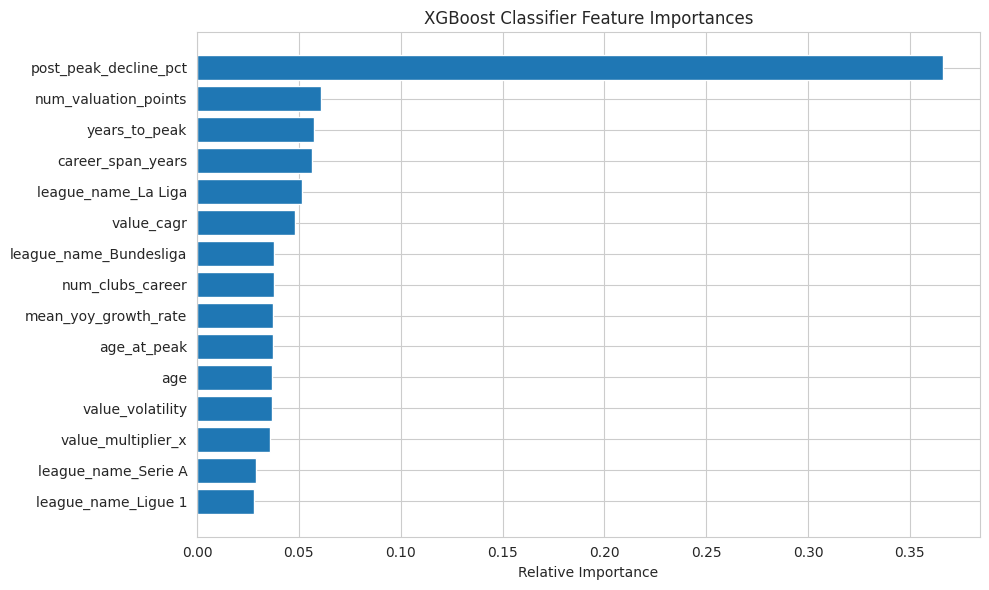

In [13]:
# ### 11.4 Feature Importance for Classification (from tuned XGBoost)

# %%
# Get feature names (same as before)
feature_names_cls = (numeric_cols + 
                     list(preprocessor_cls.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)))

xgb_cls_model = best_xgb_cls.named_steps['classifier']
importances_cls = xgb_cls_model.feature_importances_
indices_cls = np.argsort(importances_cls)[::-1]

plt.figure(figsize=(10,6))
plt.title("XGBoost Classifier Feature Importances")
plt.barh(range(len(indices_cls[:15])), importances_cls[indices_cls[:15]][::-1], align='center')
plt.yticks(range(len(indices_cls[:15])), [feature_names_cls[i] for i in indices_cls[:15]][::-1])
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


# Neural Network for Regression (Deep Learning)

2026-02-21 15:11:49.073111: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Neural Network Performance:
MAE: 26,316,642 €
RMSE: 39,208,875 €
R2: -0.402


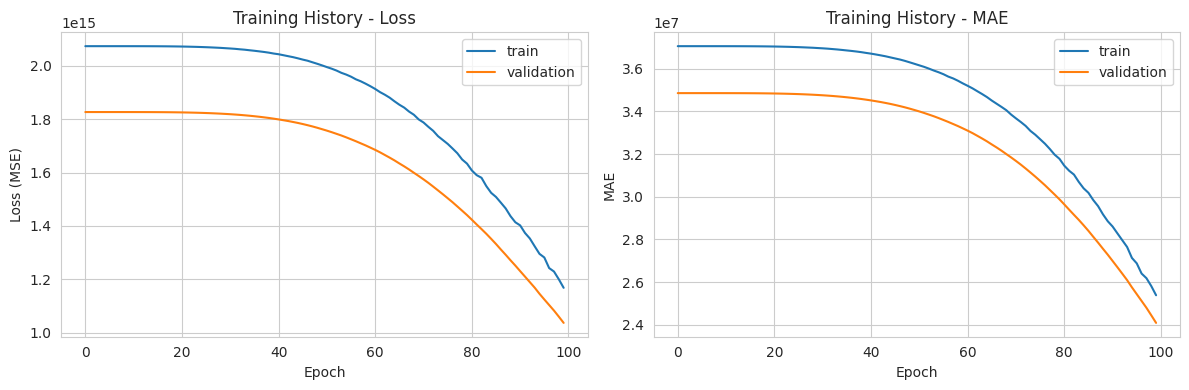

In [14]:

# Preprocess data: we need to apply the same preprocessing (scaling, one-hot) to get dense arrays.
# Fit preprocessor on training data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# The preprocessor returns a dense numpy array (no need for .toarray())
X_train_dense = X_train_transformed
X_test_dense = X_test_transformed

input_dim = X_train_dense.shape[1]

# Build model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # linear activation for regression
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Train
history = model.fit(X_train_dense, y_train, 
                    validation_split=0.2,
                    epochs=100, batch_size=32, 
                    verbose=0)  # set verbose=1 to see progress

# Evaluate
loss, mae = model.evaluate(X_test_dense, y_test, verbose=0)
y_pred_nn = model.predict(X_test_dense).flatten()
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network Performance:")
print(f"MAE: {mae:,.0f} €")
print(f"RMSE: {np.sqrt(loss):,.0f} €")
print(f"R2: {r2_nn:.3f}")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Training History - Loss')

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.title('Training History - MAE')
plt.tight_layout()
plt.show()

# Model Persistence (Save Best Models)

In [15]:


# Save the best XGBoost regressor and classifier pipelines
joblib.dump(best_xgb, 'best_xgb_regressor.pkl')
joblib.dump(best_xgb_cls, 'best_xgb_classifier.pkl')

# Also save the neural network model
model.save('nn_regressor.h5')

print("Models saved.")


Models saved.


In [16]:


# %%
# Load the saved regressor
loaded_regressor = joblib.load('best_xgb_regressor.pkl')

# Predict on a new sample (e.g., first test row)
sample = X_test.iloc[[0]]
pred = loaded_regressor.predict(sample)
print(f"Predicted value: €{pred[0]:,.0f}")
print(f"Actual value: €{y_test.iloc[0]:,.0f}")



Predicted value: €31,628,238
Actual value: €40,000,000


# demonstration

In [17]:
# Predict values
df_full = df.copy()
X_full = df_full[features].copy()

# Transform full dataset using preprocessor (fit on full data or use previously fitted preprocessor)
# It's safer to refit on full data if we want predictions on all players.
preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
X_full_transformed = preprocessor_full.fit_transform(X_full)

# Train a final regressor on all data (or use the best model we already have, but it was trained on 80% only)
# For final submission, we usually retrain on all data after validation. Let's do that.
final_regressor = XGBRegressor(**grid_search.best_params_, random_state=42)
final_regressor.fit(X_full_transformed, df_full[target])

# Predict
df_full['predicted_value_eur'] = final_regressor.predict(X_full_transformed)

# Predict trajectory using classifier (retrain on full data)
# Prepare classification target
y_full_cls = df_full['trajectory']
le_full = LabelEncoder()
y_full_cls_encoded = le_full.fit_transform(y_full_cls)

X_full_cls_transformed = preprocessor_full.fit_transform(X_full)  # reuse preprocessor

final_classifier = XGBClassifier(**grid_search_cls.best_params_, random_state=42)
final_classifier.fit(X_full_cls_transformed, y_full_cls_encoded)

df_full['predicted_trajectory'] = le_full.inverse_transform(final_classifier.predict(X_full_cls_transformed))

# %% [markdown]
# ### Create Submission‑Ready CSV

# %%
submission = df_full[['player_id', 'name', 'current_value_eur', 'predicted_value_eur', 
                      'trajectory', 'predicted_trajectory']].copy()
submission['value_error_abs'] = abs(submission['current_value_eur'] - submission['predicted_value_eur'])
submission['value_error_pct'] = (submission['value_error_abs'] / submission['current_value_eur']) * 100
submission['trajectory_correct'] = (submission['trajectory'] == submission['predicted_trajectory'])

# Save to CSV
submission.to_csv('player_predictions.csv', index=False)
print("Saved predictions to 'player_predictions.csv'")
print(submission.head(10))


Saved predictions to 'player_predictions.csv'
   player_id              name  current_value_eur  predicted_value_eur  \
0     418560    Erling Haaland        200000000.0          199909264.0   
1     433177       Bukayo Saka        130000000.0          130084832.0   
2     357662       Declan Rice        120000000.0          120006032.0   
3     568177       Cole Palmer        120000000.0          120060168.0   
4     349066    Alexander Isak        120000000.0          120001024.0   
5     687626    Moisés Caicedo        110000000.0          109881512.0   
6     598577     Florian Wirtz        110000000.0          110076864.0   
7     495666    William Saliba         90000000.0           89814720.0   
8     478573  Ryan Gravenberch         90000000.0           90056216.0   
9     648195    Enzo Fernández         85000000.0           84755632.0   

    trajectory predicted_trajectory  value_error_abs  value_error_pct  \
0      growing              growing          90736.0         0.045


--- Regression Performance on Full Dataset ---
MAE: 76,716 €
RMSE: 112,672 €
R2: 1.000

--- Classification Performance on Full Dataset ---
Accuracy: 1.000

Confusion Matrix (actual rows vs predicted columns):
predicted_trajectory  declining  falling_sharply  growing  rising_star  stable
trajectory                                                                    
declining                    73                0        0            0       0
falling_sharply               0               26        0            0       0
growing                       0                0      228            0       0
rising_star                   0                0        0          117       0
stable                        0                0        0            0      64


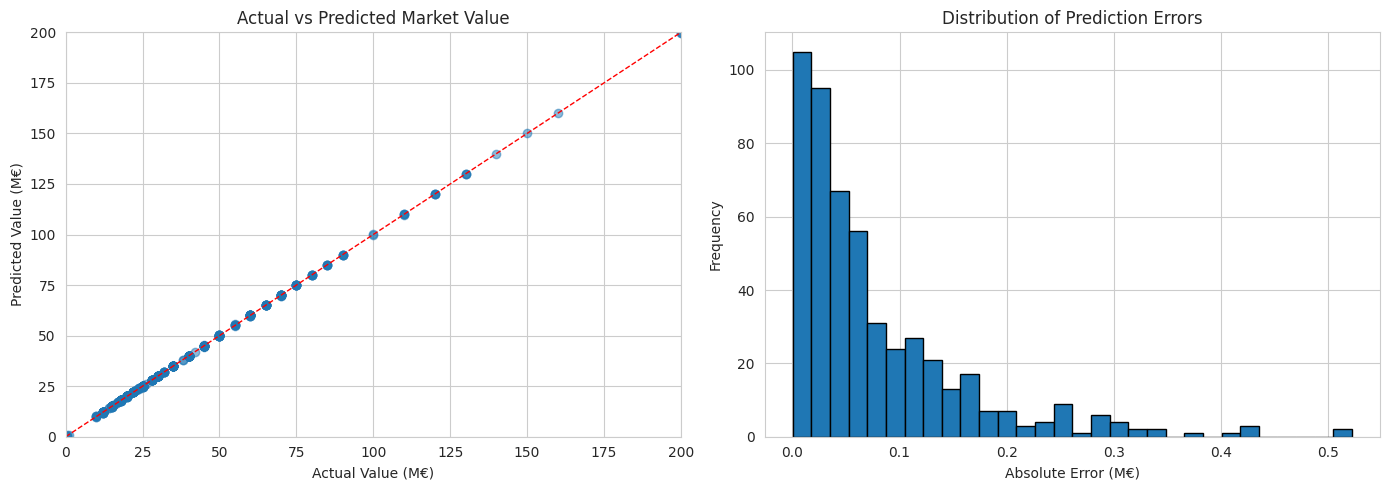

In [18]:
# %%
print("\n--- Regression Performance on Full Dataset ---")
print(f"MAE: {submission['value_error_abs'].mean():,.0f} €")
print(f"RMSE: {np.sqrt((submission['value_error_abs']**2).mean()):,.0f} €")
print(f"R2: {r2_score(submission['current_value_eur'], submission['predicted_value_eur']):.3f}")

print("\n--- Classification Performance on Full Dataset ---")
print(f"Accuracy: {submission['trajectory_correct'].mean():.3f}")
print("\nConfusion Matrix (actual rows vs predicted columns):")
print(pd.crosstab(submission['trajectory'], submission['predicted_trajectory']))

# %% [markdown]
# ## Visualize Prediction Errors

# %%
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Actual vs Predicted scatter
axes[0].scatter(submission['current_value_eur']/1e6, submission['predicted_value_eur']/1e6, alpha=0.5)
axes[0].plot([0,200], [0,200], 'r--', linewidth=1)
axes[0].set_xlabel('Actual Value (M€)')
axes[0].set_ylabel('Predicted Value (M€)')
axes[0].set_title('Actual vs Predicted Market Value')
axes[0].set_xlim(0,200)
axes[0].set_ylim(0,200)

# Error distribution
axes[1].hist(submission['value_error_abs']/1e6, bins=30, edgecolor='black')
axes[1].set_xlabel('Absolute Error (M€)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Prediction Errors')

plt.tight_layout()
plt.show()